# Phase 3 — Génération des rencontres

Objectif de cette phase : construire le jeu de données d'entraînement.

Chaque ligne = une rencontre simulée : un groupe de personnages face à un groupe de monstres, avec un label de difficulté (**Facile / Moyen / Difficile / Mortel**).

Étapes :
1. **Charger** les données brutes (monstres + personnages).
2. **Définir les tables XP officielles** D&D 5e (seuils par niveau, XP par CR).
3. **Tester la logique de label** sur une seule rencontre.
4. **Générer** ~1 000 rencontres et vérifier l'équilibre des classes.
5. **Sauvegarder** en `data/raw/encounters.csv`.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

RAW = Path.cwd().parent / "data" / "raw"

monsters = pd.read_csv(RAW / "monsters.csv")
characters = pd.read_csv(RAW / "characters_unique.csv")

print("Monstres   :", monsters.shape)
print("Personnages:", characters.shape)

Monstres   : (3207, 23)
Personnages: (7946, 35)


## 1. Tables XP officielles D&D 5e

Le système officiel évalue la difficulté d'une rencontre en comparant deux valeurs :

- **Seuil XP du groupe** : somme des seuils individuels par niveau (table du DMG, p. 82).
- **XP ajusté des monstres** : somme des XP par CR, multipliée par un facteur selon le nombre de monstres.

Si XP_ajusté ≥ seuil Mortel → Mortel, ≥ Difficile → Difficile, etc.

On définit ces deux tables ci-dessous.

In [14]:
# Seuils XP par niveau de personnage (Easy, Medium, Hard, Deadly).
# Source : DMG p. 82 — D&D 5e (2014).
XP_THRESHOLDS_BY_LEVEL = {
    1:  (25,   50,   75,   100),
    2:  (50,   100,  150,  200),
    3:  (75,   150,  225,  400),
    4:  (125,  250,  375,  500),
    5:  (250,  500,  750,  1100),
    6:  (300,  600,  900,  1400),
    7:  (350,  750,  1100, 1700),
    8:  (450,  900,  1400, 2100),
    9:  (550,  1100, 1600, 2400),
    10: (600,  1200, 1900, 2800),
    11: (800,  1600, 2400, 3600),
    12: (1000, 2000, 3000, 4500),
    13: (1100, 2200, 3400, 5100),
    14: (1250, 2500, 3800, 5700),
    15: (1400, 2800, 4300, 6400),
    16: (1600, 3200, 4800, 7200),
    17: (2000, 3900, 5900, 8800),
    18: (2100, 4200, 6300, 9500),
    19: (2400, 4900, 7300, 10900),
    20: (2800, 5700, 8500, 12700),
}

# XP accordé par CR.
# Source : DMG p. 274 — D&D 5e (2014).
XP_BY_CR = {
    0:    10,
    0.125: 25,
    0.25: 50,
    0.5:  100,
    1:    200,
    2:    450,
    3:    700,
    4:    1100,
    5:    1800,
    6:    2300,
    7:    2900,
    8:    3900,
    9:    5000,
    10:   5900,
    11:   7200,
    12:   8400,
    13:   10000,
    14:   11500,
    15:   13000,
    16:   15000,
    17:   18000,
    18:   20000,
    19:   22000,
    20:   25000,
    21:   33000,
    22:   41000,
    23:   50000,
    24:   62000,
    25:   75000,
    26:   90000,
    27:   105000,
    28:   120000,
    29:   135000,
    30:   155000,
}

# Multiplicateurs XP selon le nombre de monstres dans la rencontre.
# Source : DMG p. 82.
XP_MULTIPLIERS = [
    (1,  1,   1.0),
    (2,  2,   1.5),
    (3,  6,   2.0),
    (7,  10,  2.5),
    (11, 14,  3.0),
    (15, None, 4.0),
]


def get_xp_multiplier(n_monsters: int) -> float:
    """Retourne le multiplicateur XP pour n monstres."""
    for low, high, mult in XP_MULTIPLIERS:
        if high is None or low <= n_monsters <= high:
            return mult
    return 4.0


# Vérification rapide
print("Multiplicateur pour 1 monstre  :", get_xp_multiplier(1))
print("Multiplicateur pour 4 monstres :", get_xp_multiplier(4))
print("Multiplicateur pour 8 monstres :", get_xp_multiplier(8))
print("Multiplicateur pour 20 monstres:", get_xp_multiplier(20))

Multiplicateur pour 1 monstre  : 1.0
Multiplicateur pour 4 monstres : 2.0
Multiplicateur pour 8 monstres : 2.5
Multiplicateur pour 20 monstres: 4.0


## 2. Logique de label sur une rencontre unique

Avant de générer 1 000 rencontres, on valide la logique sur un exemple construit à la main.

**Exemple** : 4 personnages de niveau 5 affrontent 3 orcs (CR 1/2 chacun).

Calcul attendu :
- Seuil du groupe (niveau 5) : Easy = 4×250, Medium = 4×500, Hard = 4×750, Deadly = 4×1100
- XP monstres brut : 3 × 100 (CR 1/2) = 300 XP
- Multiplicateur pour 3 monstres : ×2.0 → XP ajusté = 600 XP
- 600 ≥ Medium (1000) ? Non. 600 ≥ Easy (1000) ? Non... attendons le résultat réel.

On implémente deux fonctions :
- `party_thresholds(levels)` → (easy, medium, hard, deadly)
- `label_encounter(levels, crs)` → difficulté sous forme de chaîne

In [15]:
def party_thresholds(levels: list[int]) -> tuple[int, int, int, int]:
    """Retourne les seuils XP cumulés du groupe (easy, medium, hard, deadly).

    Args:
        levels: Liste des niveaux des personnages du groupe.

    Returns:
        Tuple (easy, medium, hard, deadly) en XP total.
    """
    easy = medium = hard = deadly = 0
    for lvl in levels:
        e, m, h, d = XP_THRESHOLDS_BY_LEVEL[lvl]
        easy   += e
        medium += m
        hard   += h
        deadly += d
    return easy, medium, hard, deadly


def label_encounter(levels: list[int], crs: list[float]) -> str:
    """Attribue un label de difficulté à une rencontre D&D 5e.

    Args:
        levels: Niveaux des personnages joueurs.
        crs:    CR de chaque monstre dans la rencontre.

    Returns:
        "Easy", "Medium", "Hard" ou "Deadly".
    """
    easy, medium, hard, deadly = party_thresholds(levels)

    raw_xp = sum(XP_BY_CR.get(cr, 0) for cr in crs)
    multiplier = get_xp_multiplier(len(crs))
    adjusted_xp = raw_xp * multiplier

    if adjusted_xp >= deadly:
        return "Deadly"
    if adjusted_xp >= hard:
        return "Hard"
    if adjusted_xp >= medium:
        return "Medium"
    return "Easy"


# --- Test sur l'exemple du markdown ---
party_levels = [5, 5, 5, 5]
monster_crs  = [0.5, 0.5, 0.5]   # 3 orcs CR 1/2

easy, medium, hard, deadly = party_thresholds(party_levels)
raw_xp      = sum(XP_BY_CR[cr] for cr in monster_crs)
multiplier  = get_xp_multiplier(len(monster_crs))
adjusted_xp = raw_xp * multiplier
label       = label_encounter(party_levels, monster_crs)

print(f"Seuils du groupe    : Easy={easy}  Medium={medium}  Hard={hard}  Deadly={deadly}")
print(f"XP monstres brut    : {raw_xp}")
print(f"Multiplicateur      : ×{multiplier}")
print(f"XP ajusté           : {adjusted_xp}")
print(f"Label               : {label}")

Seuils du groupe    : Easy=1000  Medium=2000  Hard=3000  Deadly=4400
XP monstres brut    : 300
Multiplicateur      : ×2.0
XP ajusté           : 600.0
Label               : Easy


## 3. Préparation des données pour l'échantillonnage

Avant de générer des rencontres on nettoie les deux datasets :

**Monstres** :
- Garder seulement les CR présents dans `XP_BY_CR` (certains CRs exotiques ou NaN planteraient le générateur).
- Dédupliquer par nom en gardant la version "5e Core Rules" en priorité, sinon la première occurrence (même monstre publié dans plusieurs sourcebooks).

**Personnages** :
- Supprimer les valeurs aberrantes identifiées en Phase 2 : HP ≤ 0, HP > 1 000, AC > 40.
- Ne garder que les colonnes utiles au ML (level, HP, AC, stats, classe).

In [16]:
VALID_CRS = set(XP_BY_CR.keys())

# --- Monstres ---
# 1. Garder uniquement les CR valides
monsters_clean = monsters[monsters["cr"].isin(VALID_CRS)].copy()

# 2. Dédupliquer par nom : priorité à "5e Core Rules", sinon première occurrence
monsters_clean["_is_core"] = monsters_clean["document__title"] == "5e Core Rules"
monsters_clean = (
    monsters_clean
    .sort_values("_is_core", ascending=False)   # core en premier
    .drop_duplicates(subset="name", keep="first")
    .drop(columns="_is_core")
    .reset_index(drop=True)
)

print(f"Monstres — avant : {len(monsters)}  après nettoyage : {len(monsters_clean)}")
print(f"CRs représentés  : {sorted(monsters_clean['cr'].unique())}")

# --- Personnages ---
CHAR_COLS = ["level", "HP", "AC", "Str", "Dex", "Con", "Int", "Wis", "Cha", "justClass"]

chars_clean = (
    characters[CHAR_COLS]
    .dropna()
    .query("1 <= level <= 20")
    .query("0 < HP <= 1000")
    .query("5 <= AC <= 40")
    .reset_index(drop=True)
)

print(f"\nPersonnages — avant : {len(characters)}  après nettoyage : {len(chars_clean)}")
print(f"Niveaux représentés : {sorted(chars_clean['level'].unique())}")

Monstres — avant : 3207  après nettoyage : 2319
CRs représentés  : [np.float64(0.0), np.float64(0.125), np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(30.0)]

Personnages — avant : 7946  après nettoyage : 7936
Niveaux représentés : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


## 4. Générateur de rencontres

### Stratégie d'échantillonnage

Pour chaque rencontre :
1. **Groupe** : tirer `party_size` (3–5) personnages avec remplacement depuis `chars_clean`.  
   Pour éviter le biais vers le niveau 1, on tire d'abord un *niveau cible* (uniforme 1–20), puis on filtre les personnages à ±2 niveaux autour de ce cible.
2. **Monstres** : tirer `n_monsters` (1–6) monstres dont le CR est dans la plage `[avg_level/4 − 1, avg_level + 3]` — assez large pour couvrir les 4 difficultés.
3. **Label** : appliquer `label_encounter()` définie à l'étape 2.

### Features extraites par rencontre

| Catégorie | Features |
|---|---|
| Groupe | `party_size`, `party_avg_level`, `party_avg_hp`, `party_avg_ac`, `party_avg_str/dex/con` |
| Monstres | `monster_count`, `monster_avg_cr`, `monster_avg_hp`, `monster_avg_ac` |
| XP | `xp_raw`, `xp_adjusted`, `xp_ratio` (XP ajusté / seuil Mortel) |
| Cible | `difficulty` (Easy / Medium / Hard / Deadly) |

In [17]:
def sample_encounter(
    chars_df: pd.DataFrame,
    monsters_df: pd.DataFrame,
    rng: np.random.Generator,
) -> dict:
    """Génère une rencontre aléatoire et retourne ses features + label.

    Args:
        chars_df:    DataFrame personnages nettoyé.
        monsters_df: DataFrame monstres nettoyé.
        rng:         Générateur numpy pour la reproductibilité.

    Returns:
        Dictionnaire de features prêt à être ajouté au dataset.
    """
    # 1. Tirer un niveau cible (uniforme 1–20) puis filtrer les personnages proches
    target_level = int(rng.integers(1, 21))
    pool = chars_df[chars_df["level"].between(max(1, target_level - 2), min(20, target_level + 2))]
    if len(pool) < 3:
        pool = chars_df  # fallback si niveau rare

    party_size = int(rng.integers(2, 7))  # 2 à 6 personnages
    party = pool.sample(n=party_size, replace=True)
    party_levels = party["level"].tolist()
    party_avg_level = party["level"].mean()

    # 2. Seuils XP du groupe
    easy, medium, hard, deadly = party_thresholds(party_levels)

    # 3. Filtrer les monstres dans une plage CR cohérente avec le niveau
    cr_min = max(0, party_avg_level / 4 - 1)
    cr_max = party_avg_level + 3
    valid_monsters = monsters_df[monsters_df["cr"].between(cr_min, cr_max)]
    if len(valid_monsters) < 5:
        valid_monsters = monsters_df  # fallback

    n_monsters = int(rng.integers(1, 7))
    encounter_monsters = valid_monsters.sample(n=n_monsters, replace=True)
    monster_crs = encounter_monsters["cr"].tolist()

    # 4. XP et label
    raw_xp = sum(XP_BY_CR[cr] for cr in monster_crs)
    multiplier = get_xp_multiplier(n_monsters)
    adjusted_xp = raw_xp * multiplier
    label = label_encounter(party_levels, monster_crs)

    return {
        "party_size":       party_size,
        "party_avg_level":  round(party_avg_level, 2),
        "party_avg_hp":     round(party["HP"].mean(), 1),
        "party_avg_ac":     round(party["AC"].mean(), 1),
        "party_avg_str":    round(party["Str"].mean(), 1),
        "party_avg_dex":    round(party["Dex"].mean(), 1),
        "party_avg_con":    round(party["Con"].mean(), 1),
        "monster_count":    n_monsters,
        "monster_avg_cr":   round(sum(monster_crs) / n_monsters, 3),
        "monster_avg_hp":   round(encounter_monsters["hit_points"].mean(), 1),
        "monster_avg_ac":   round(encounter_monsters["armor_class"].mean(), 1),
        "xp_raw":           int(raw_xp),
        "xp_adjusted":      int(adjusted_xp),
        "xp_ratio":         round(adjusted_xp / deadly, 3),
        "threshold_easy":   easy,
        "threshold_medium": medium,
        "threshold_hard":   hard,
        "threshold_deadly": deadly,
        "difficulty":       label,
    }

In [18]:
N_ENCOUNTERS = 1000
rng = np.random.default_rng(42)

rows = [
    sample_encounter(chars_clean, monsters_clean, rng)
    for _ in range(N_ENCOUNTERS)
]
encounters = pd.DataFrame(rows)

print(encounters.shape)
encounters.head()

(1000, 19)


,party_size,party_avg_level,party_avg_hp,party_avg_ac,party_avg_str,party_avg_dex,party_avg_con,monster_count,monster_avg_cr,monster_avg_hp,monster_avg_ac,xp_raw,xp_adjusted,xp_ratio,threshold_easy,threshold_medium,threshold_hard,threshold_deadly,difficulty
0,5,1.60,13.0,14.6,12.0,15.6,12.2,4,2.000,57.5,12.2,1800,3600,4.000,200,400,600,900,Deadly
1,4,8.50,88.5,15.8,13.5,13.0,16.2,6,6.667,126.2,15.3,17900,35800,3.768,2050,4150,6300,9500,Deadly
2,5,1.00,8.0,13.0,10.8,10.6,12.6,2,3.000,57.0,13.5,1550,2325,4.650,125,250,375,500,Deadly
3,4,3.25,33.0,17.2,13.8,13.8,14.8,6,1.188,34.5,12.8,1725,3450,2.029,350,700,1050,1700,Deadly
4,5,15.00,143.4,17.4,17.2,15.2,13.6,5,7.600,135.8,16.0,23600,47200,1.470,7050,14100,21500,32100,Deadly


Distribution des labels :
difficulty
Easy      219
Medium     91
Hard      124
Deadly    566

Total : 1000  |  Idéal par classe : 250


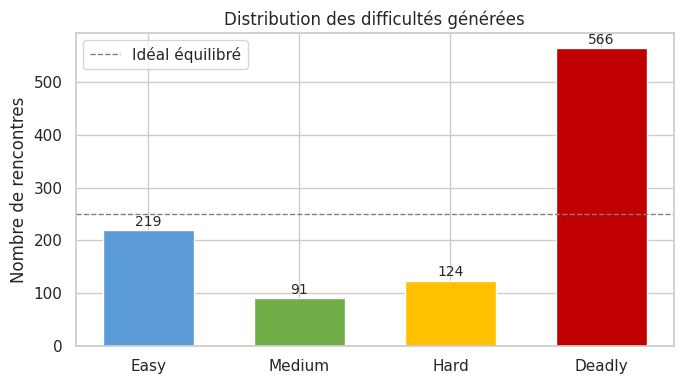

In [19]:
ORDER = ["Easy", "Medium", "Hard", "Deadly"]
counts = encounters["difficulty"].value_counts().reindex(ORDER)

print("Distribution des labels :")
print(counts.to_string())
print(f"\nTotal : {counts.sum()}  |  Idéal par classe : {N_ENCOUNTERS // 4}")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#5b9bd5", "#70ad47", "#ffc000", "#c00000"]
ax.bar(ORDER, counts.values, color=colors, edgecolor="white", width=0.6)
ax.axhline(N_ENCOUNTERS // 4, color="grey", linestyle="--", linewidth=1, label="Idéal équilibré")
for i, (label, val) in enumerate(zip(ORDER, counts.values)):
    ax.text(i, val + 8, str(val), ha="center", fontsize=10)
ax.set_title("Distribution des difficultés générées")
ax.set_ylabel("Nombre de rencontres")
ax.legend()
plt.tight_layout()
plt.show()

## 4b. Génération stratifiée — rééquilibrage des classes

La distribution ci-dessus est déséquilibrée : Deadly domine, Medium est sous-représenté.

### Principe

On remplace le tirage naïf par une **boucle avec quatre buckets** — un par difficulté.
À chaque itération :
1. On génère une rencontre aléatoire.
2. On regarde son label.
3. Si le bucket correspondant n'est **pas encore plein** (< 250), on l'y ajoute.
4. Sinon, on la jette et on recommence.

La boucle s'arrête quand les quatre buckets atteignent 250 chacun → **1 000 rencontres parfaitement équilibrées**.

> Le générateur peut tourner plusieurs milliers de fois pour remplir les classes rares (Medium, Hard). C'est normal et peu coûteux — chaque rencontre se calcule en microsecondes.

Tentatives totales : 2839
Taux d'acceptation : 35.2%

Distribution finale :
difficulty
Easy      250
Medium    250
Hard      250
Deadly    250


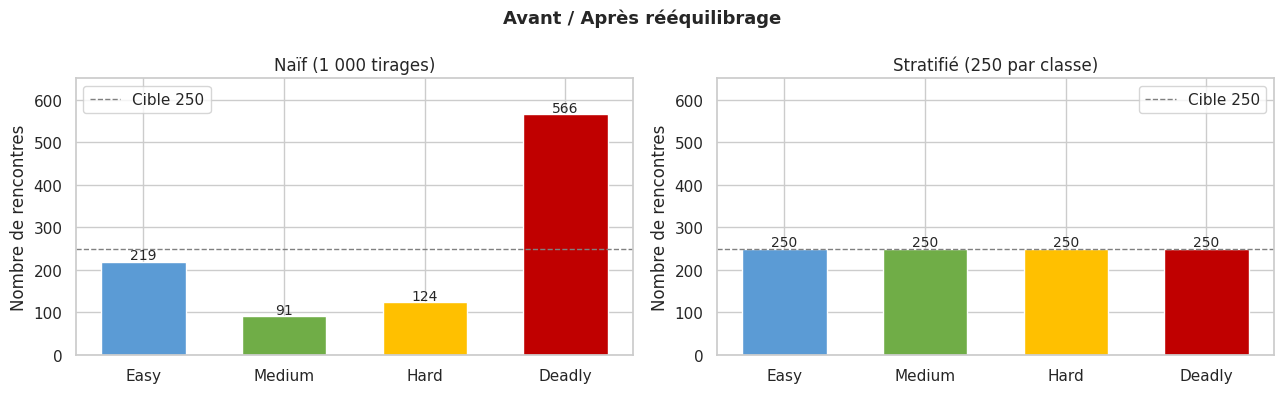

In [20]:
TARGET_PER_CLASS = 250
CLASSES = ["Easy", "Medium", "Hard", "Deadly"]

rng_strat = np.random.default_rng(42)
buckets: dict[str, list[dict]] = {c: [] for c in CLASSES}
total_attempts = 0

while any(len(buckets[c]) < TARGET_PER_CLASS for c in CLASSES):
    row = sample_encounter(chars_clean, monsters_clean, rng_strat)
    label = row["difficulty"]
    if len(buckets[label]) < TARGET_PER_CLASS:
        buckets[label].append(row)
    total_attempts += 1

encounters_balanced = pd.DataFrame([row for c in CLASSES for row in buckets[c]])

print(f"Tentatives totales : {total_attempts}")
print(f"Taux d'acceptation : {len(encounters_balanced) / total_attempts * 100:.1f}%")
print()
print("Distribution finale :")
print(encounters_balanced["difficulty"].value_counts().reindex(CLASSES).to_string())

# Visualisation
counts_bal = encounters_balanced["difficulty"].value_counts().reindex(CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Avant / Après rééquilibrage", fontsize=13, fontweight="bold")

colors = ["#5b9bd5", "#70ad47", "#ffc000", "#c00000"]
for ax, (cnt, title) in zip(axes, [(counts, "Naïf (1 000 tirages)"), (counts_bal, "Stratifié (250 par classe)")]):
    ax.bar(CLASSES, cnt.values, color=colors, edgecolor="white", width=0.6)
    ax.axhline(TARGET_PER_CLASS, color="grey", linestyle="--", linewidth=1, label="Cible 250")
    for i, val in enumerate(cnt.values):
        ax.text(i, val + 6, str(val), ha="center", fontsize=10)
    ax.set_title(title)
    ax.set_ylabel("Nombre de rencontres")
    ax.set_ylim(0, max(counts.max(), TARGET_PER_CLASS) * 1.15)
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Sauvegarde

On sauvegarde le dataset équilibré dans `data/raw/encounters.csv`.
Un aperçu final confirme le shape, les types de colonnes et l'absence de valeurs manquantes.

In [ ]:
out_path = RAW / "encounters.csv"
encounters_balanced.to_csv(out_path, index=False)

print(f"Fichier sauvegardé : {out_path}")
print(f"Shape              : {encounters_balanced.shape}")
print(f"Valeurs manquantes : {encounters_balanced.isnull().sum().sum()}")
print()
print("Types de colonnes :")
print(encounters_balanced.dtypes.to_string())
print()
encounters_balanced.head()

---

## ⚠️ Avertissement : limites de la stratification parfaite

Le dataset sauvegardé est **artificiellement équilibré** à 250 rencontres par classe. C'est un bon point de départ pour un premier modèle, mais il faut garder en tête trois risques :

1. **Prior irréaliste** — en D&D, Easy et Medium sont bien plus fréquents que Deadly. Le modèle apprend une distribution qui ne reflète pas la réalité d'une table de jeu.
2. **Faible diversité sur les classes rares** — les 250 exemples Medium et Hard ont été filtrés parmi des milliers de tentatives ; ils occupent une zone étroite de l'espace des features et peuvent conduire à de l'overfitting.
3. **Perte de diversité sur les classes majoritaires** — des centaines d'exemples Deadly valides ont été jetés pour maintenir l'équilibre.

### Solution recommandée pour la Phase 5

Lors de l'optimisation du modèle, **remplacer la stratification stricte par `class_weight="balanced"`** dans scikit-learn (ou `scale_pos_weight` pour XGBoost).

Cette approche conserve la distribution naturelle des données (plus riche et plus diversifiée) tout en compensant le déséquilibre au niveau de la fonction de perte du modèle.